# Figures 1 and 2: shelf SWMT and export densities

We plot the surface water mass transformation (SWMT) and lateral import/export of water denser than each $\sigma_2$ class on the Antarctic continental shelf in the Historical/SSP5-8.5 experiment (Figure 1), and the minimum densities of Dense Shelf Water formation and export in both experiments (Figure 2).
The shelf budget is produced by `01_prepare_dsw_wmt_budget` and the minimum densities by `03_prepare_dsw_densities_and_periods`.

In [1]:
import sys

import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import xarray as xr
from matplotlib.colors import ListedColormap, TwoSlopeNorm

sys.path.insert(0, "../src")
from paths import outputdir, plotsdir
from plotting import to_tg, expt_labels, set_style

set_style(dpi=150)


reference_period = (1900, 2000)  # historical averaging window
future_period = (2090, 2100)  # end-of-century averaging window


def extend_center_color(cmap, vmin, vmax, center_min=-1, center_max=1, n_colors=256):
    """Colormap whose values in [center_min, center_max] all take the center color."""
    colors = cmap(np.linspace(0, 1, n_colors))
    center_idx = n_colors // 2
    half_width = int(n_colors * (center_max - center_min) / (vmax - vmin) / 2)
    colors[center_idx - half_width:center_idx + half_width] = colors[center_idx]
    return ListedColormap(colors)

In [2]:
ds = xr.open_dataset(outputdir("Southern_Ocean_DSW_1000m_WMT_Budget.zarr"))
ds_max_swmt = xr.open_dataset(outputdir("Southern_Ocean_DSW_1000m_max_SWMT.zarr"))
ds_max_export = xr.open_dataset(outputdir("Southern_Ocean_DSW_1000m_max_export.zarr"))

In [3]:
ds["surface_boundary_fluxes"] = ds["boundary_fluxes"] - ds["bottom_flux_heat"]
ds_yearly = (
    ds[["surface_boundary_fluxes", "convergent_mass_transport"]]
    .fillna(0.0).groupby("time.year").mean("time")
    .sel(sigma2_l_target=slice(20, None))
)
shelf_swmt = ds_yearly["surface_boundary_fluxes"]
shelf_psi = ds_yearly["convergent_mass_transport"]

## Figure 1

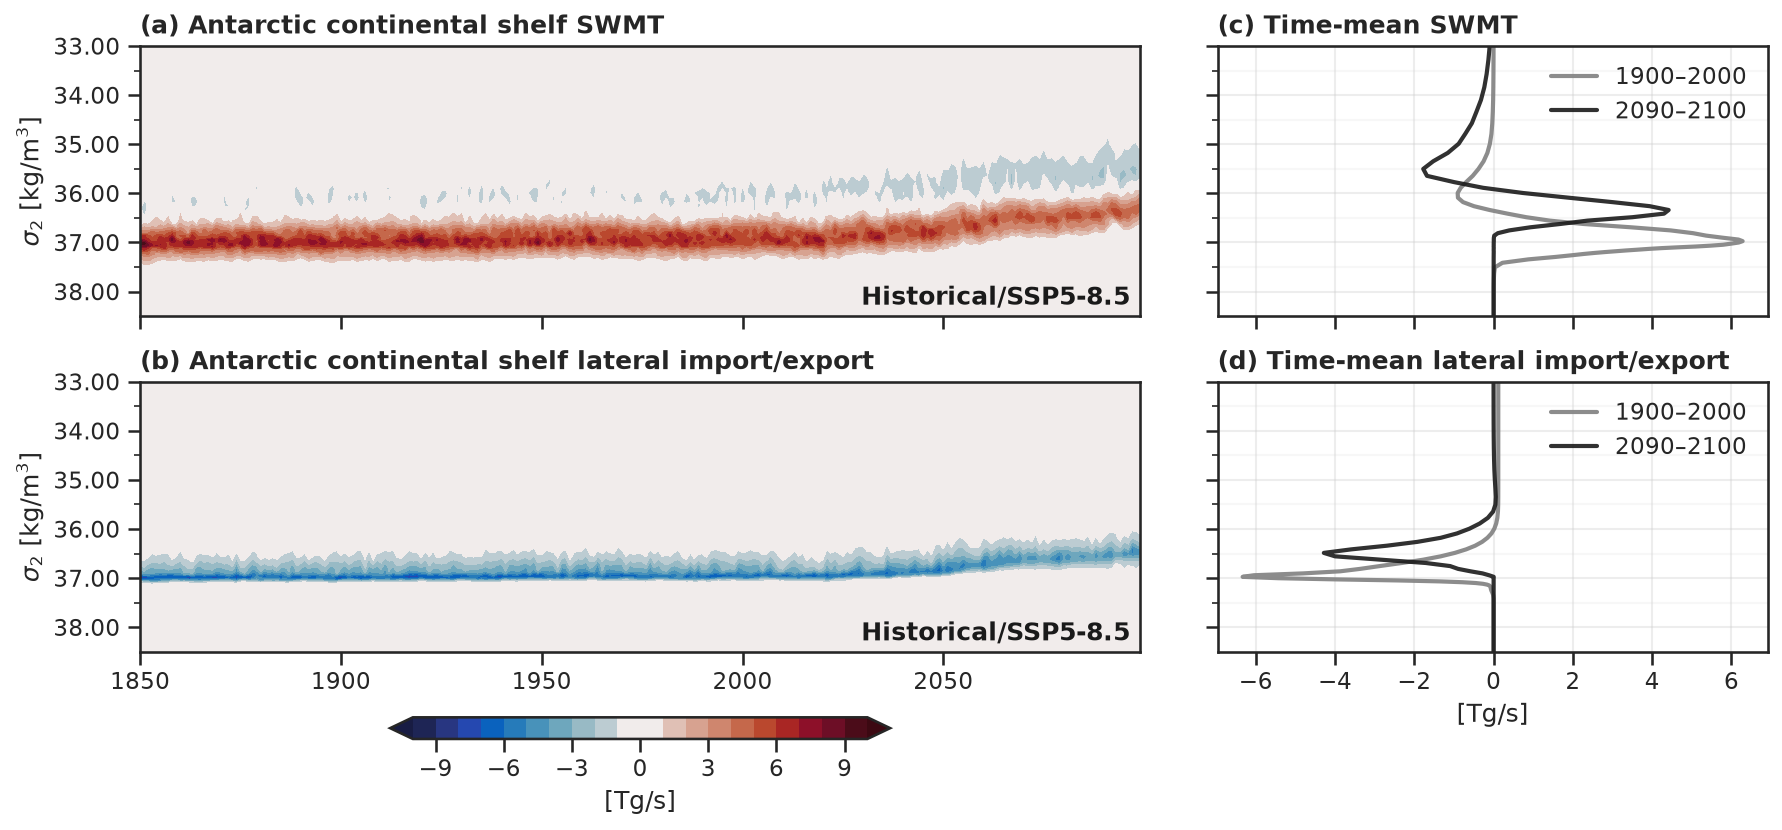

In [4]:
exp = "forced"
periods = [reference_period, future_period]
period_labels = [f"{start}–{end}" for start, end in periods]
period_colors = ["grey", "k"]

density = shelf_swmt.sigma2_l_target.values
years, densities = np.meshgrid(shelf_swmt.year.values, density)

major_ticks = np.arange(32.0, 38.1, 1.0)
all_ticks = np.arange(32.0, 38.1, 0.5)
minor_ticks = all_ticks[~np.isclose(all_ticks[:, None], major_ticks).any(axis=1)]

levels = np.arange(-10, 10 + 0.01, 1.0)
cmap = extend_center_color(cmo.balance, levels.min(), levels.max(), center_min=-1, center_max=1)
norm = TwoSlopeNorm(vmin=levels.min(), vcenter=0.0, vmax=levels.max())

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(3, 2, width_ratios=[1, 0.55], height_ratios=[1, 1, 0.08], wspace=0.1, hspace=0.35)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
ax2 = fig.add_subplot(gs[0, 1], sharey=ax0)
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2, sharey=ax0)
cax = fig.add_subplot(gs[2, 0])
ax0.tick_params(labelbottom=False)
ax2.tick_params(labelbottom=False)

cm = ax0.contourf(years, densities, to_tg * shelf_swmt.sel(exp=exp).T,
                  levels=levels, extend="both", cmap=cmap, norm=norm)
ax1.contourf(years, densities, to_tg * shelf_psi.sel(exp=exp).T,
             levels=levels, extend="both", cmap=cmap, norm=norm)
ax0.set_title("(a) Antarctic continental shelf SWMT", loc="left", fontweight="bold")
ax1.set_title("(b) Antarctic continental shelf lateral import/export", loc="left", fontweight="bold")
for a in (ax0, ax1):
    a.text(0.99, 0.02, expt_labels[exp], transform=a.transAxes, ha="right", va="bottom",
           color="k", fontweight="bold")

cb = fig.colorbar(cm, cax=cax, orientation="horizontal")
cb.set_label("[Tg/s]")
pos = cax.get_position()  # shrink the colorbar to half width, centered
cax.set_position([pos.x0 + pos.width / 4, pos.y0, pos.width / 2, pos.height])

for a, field in zip((ax2, ax3), (shelf_swmt, shelf_psi)):
    for (start, end), label, color in zip(periods, period_labels, period_colors):
        a.plot(to_tg * field.sel(exp=exp, year=slice(start, end)).mean("year"), density,
               lw=2, label=label, color=color, alpha=0.9)
    a.grid(which="major", alpha=0.35)
    a.grid(which="minor", alpha=0.15)
    a.legend(frameon=False)
ax2.set_title("(c) Time-mean SWMT", loc="left", fontweight="bold")
ax3.set_title("(d) Time-mean lateral import/export", loc="left", fontweight="bold")
ax3.set_xlabel("[Tg/s]")

for i, a in enumerate((ax0, ax1, ax2, ax3)):
    a.tick_params(bottom=True, left=True)
    if i < 2:
        a.set_ylabel(r"$\sigma_2$ [kg/m$^3$]")
    a.set_yticks(major_ticks)
    a.set_yticks(minor_ticks, minor=True)
    a.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    a.yaxis.set_minor_formatter(mticker.NullFormatter())
    a.tick_params(axis="y", which="major", length=6, width=1.2, labelleft=i < 2)
    a.tick_params(axis="y", which="minor", length=3, width=0.8, labelleft=False)
    a.set_ylim(38.5, 33.0)

fig.savefig(plotsdir("fig01_acs_swmt_and_psi.png"), dpi=350, bbox_inches="tight")

## Figure 2

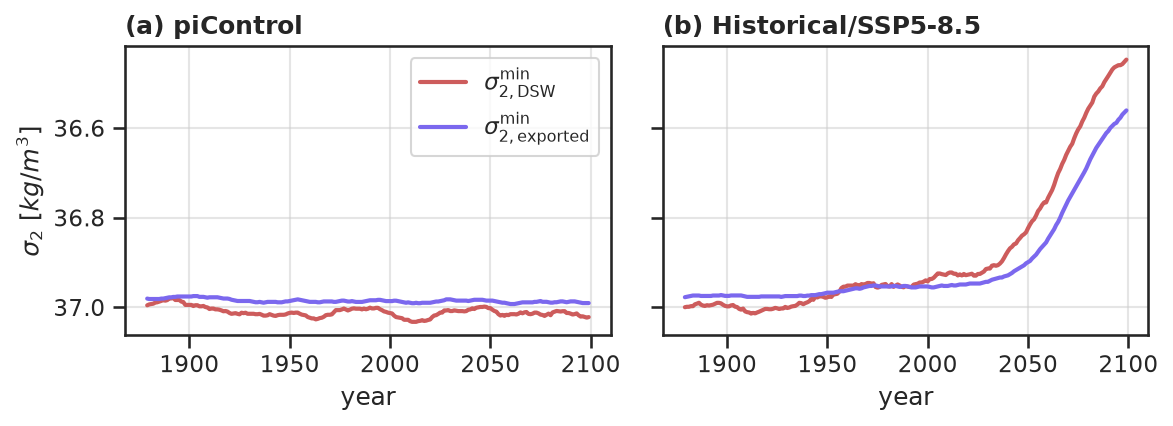

In [5]:
year_rolling = 30  # backward rolling window [years]

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
for letter, exp, ax in zip(["a", "b"], ["control", "forced"], axes):
    dsw_density = ds_max_swmt["max_surface_boundary_flux_density"].sel(exp=exp)
    export_density = ds_max_export["max_export_density"].sel(exp=exp)
    dsw_density = dsw_density.rolling(year=year_rolling).mean()
    export_density = export_density.rolling(year=year_rolling).mean()
    ax.plot(dsw_density.year, dsw_density, lw=2, c="indianred",
            label=r"$\sigma_{2,\substack{\mathrm{DSW}}}^{\min}$")
    ax.plot(export_density.year, export_density, lw=2, c="mediumslateblue",
            label=r"$\sigma_{2,\substack{\mathrm{exported}}}^{\min}$")
    ax.set_title(f"({letter}) {expt_labels[exp]}", loc="left", fontweight="bold")
    ax.grid(alpha=0.5)
    ax.set_xlabel("year")
axes[0].invert_yaxis()
axes[0].legend()
axes[0].set_ylabel(r"$\sigma_2$ $[kg/m^3]$")

fig.tight_layout()
fig.savefig(plotsdir("fig02_acs_swmt_and_export_densities.png"), dpi=350, bbox_inches="tight")